In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Specify all CSV filepaths as a list of str

In [2]:
filepaths_initial = [f"../data/res{i}_destructive_test.csv" for i in range(1,4)]
filepaths_repeat = [f"../data/res{i}_repeat.csv" for i in range(1,4)]
#filepaths_repeat.append("../data/res5_new.csv")

## Define functions for prepping and plotting data

In [3]:
def prep_df(df, truncate_last=0, gain=1.0, offset=0.0):
    """
    Inputs:
    df : pandas DataFrame to process
    truncate_last : int, number of valid datapoints to drop from end of DataFrame
    """
    df = df.copy()
    NOMINAL_LOAD_RESISTANCE = 10  # Ohms
    CURR_SENSE_RESISTANCE = 0.1   # Ohms

    # Remove all data to after first ADC error value (where current reads as -10 mA)
    mask = (df["Current (mA)"] == -10.0)
    if mask.any():
        idx = mask.idxmax()   # index of first True
        df = df.iloc[:idx-1]   

    # Remove any low-drive values from experiment
    df = df[df["Current (mA)"] >= 20.0]

    # Remove last N values
    if truncate_last > 0:
        df = df.iloc[:(-1*truncate_last)]

    # Apply gain and offset corrections if desired
    if gain != 1.0 or offset != 0.0:
        df["Source voltage (V)"] = gain * ( df["Source voltage (V)"] - offset )
        df["Load voltage (V)"] = gain * ( df["Load voltage (V)"] - offset )
        df["Curr sense voltage (V)"] = gain * ( df["Curr sense voltage (V)"] - offset )

        # Recalculate current, since this is calculated from voltage data
        df["Current (mA)"] = df["Curr sense voltage (V)"] / CURR_SENSE_RESISTANCE * 1000

    # Add columns
    df["nominal_load_voltage"] = df["Current (mA)"] / 1000 * NOMINAL_LOAD_RESISTANCE  # units: Volts
    df["calc_resistance"] = df["Load voltage (V)"] / df["Current (mA)"] * 1000  # units: Ohms
    df["power"] = df["Load voltage (V)"] * df["Current (mA)"]  # units: mW
    return df

In [4]:
def plot_resistance(dfs, labels=None, x_axis="Current (mA)", 
                    ylabel=None, xlabel=None, title=None, 
                    nominal_resistance=10, tolerance=0.01,
                    normalize_y=False, normalize_x_value=None):
    """
    Plot the calculated resistances from multiple DataFrames on one plot.

    dfs: iterable of pandas DataFrames
    labels: optional iterable of legend labels
    x_axis: str specifying column to plot on x-axis
    ylabel: str to label y-axis on plot
    xlabel: str to label x-axis on plot
    title: str to use as plot title
    normalize_y: bool to indicate whether resistance values should be normalized
    normalize_x_value: float to normalize x-axis values, disabled if None
    """
    # Input validation
    if labels is None:
        labels = [f"res_{i}" for i in range(len(dfs))]
    else:
        if len(labels) != len(dfs):
            raise Exception("Input 'labels' must be same length as 'dfs'")

    if not isinstance(xlabel, str):
        raise Exception("Input 'xlabel' must be of type str")

    if not isinstance(ylabel, str):
        raise Exception("Input 'ylabel' must be of type str")

    if not isinstance(title, str):
        raise Exception("Input 'title' must be of type str")

    if not isinstance(nominal_resistance, int) and not isinstance(nominal_resistance, float):
        raise Exception("Input 'nominal_resistance' must be of type int or float")

    if not isinstance(tolerance, float) or tolerance < 0.0 or tolerance > 1.0:
        raise Exception("Input 'tolerance' must be a float between 0.0 and 1.0")

    if not isinstance(normalize_y, bool):
            raise Exception("Input 'normalize_y' must be either True or False")
            
    if normalize_x_value is not None:
        if not isinstance(normalize_x_value, float) and not isinstance(normalize_x_value, int):
            raise Exception("Input 'normalize_x_value' must be int or float")

    #dfs = list(dfs)
    #n_traces = len(dfs)
    NOMINAL_LOAD_RESISTANCE = float(nominal_resistance) 

    # Plot data
    fig, ax = plt.subplots()
    x_min = 999
    x_max = 0
    for df, label in zip(dfs, labels):
        df = df.copy()
        if normalize_y:
            df["calc_resistance"] = df["calc_resistance"] / NOMINAL_LOAD_RESISTANCE
        if normalize_x_value is not None:
            df[x_axis] = df[x_axis] / normalize_x_value
        x_min = min(x_min, min(df[x_axis]))
        x_max = max(x_max, max(df[x_axis]))
        ax.plot(df[x_axis], df["calc_resistance"], label=str(label))

    # Normalize nominal values and labels, if enabled
    nominal_value = 1.0 if normalize_y else NOMINAL_LOAD_RESISTANCE
    
    if ylabel is None:
        ylabel = "Resistance (Ohms)" if normalize_y else "Resistance (normalized)"
    if xlabel is None:
        xlabel = f"{x_axis} (normalized)" if normalize_x_value is not None else x_axis

    # Plot nominal and tolerance values
    ones_line = np.ones(2)
    nominal_value = 1.0 if normalize_y else NOMINAL_LOAD_RESISTANCE
    ax.plot([x_min, x_max], nominal_value * ones_line, 'k--')
    ax.plot([x_min, x_max], nominal_value * (1-tolerance) * ones_line, 'r--')
    ax.plot([x_min, x_max], nominal_value * (1+tolerance) * ones_line, 'r--')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()
    if title is not None:
        ax.set_title(title)
    plt.show()

## Main block: Extract, prep, and plot data

Extract data into DataFrames and prep for analysis

In [21]:
# Extract data into DataFrames and prep for analysis
dfs_initial = [pd.read_csv(filepath) for filepath in filepaths_initial]
dfs_initial_clean = [prep_df(df) for df in dfs_initial]

dfs_repeat = [pd.read_csv(filepath) for filepath in filepaths_repeat]
dfs_repeat_clean = [prep_df(df, truncate_last=5, gain=0.6/0.584) for df in dfs_repeat]

In [23]:
dfs_repeat_clean[0]

,Time (s),Source voltage (V),Load voltage (V),Curr sense voltage (V),Current (mA),nominal_load_voltage,calc_resistance,power
0,0.027123,0.004495,0.471704,0.004623,46.232877,0.462329,10.202778,21.808222
1,0.255574,0.467209,0.471832,0.004623,46.232877,0.462329,10.205556,21.814160
2,0.484006,0.467337,0.471961,0.004623,46.232877,0.462329,10.208333,21.820097
3,0.714902,0.466952,0.471704,0.004623,46.232877,0.462329,10.202778,21.808222
4,0.947044,0.466824,0.471447,0.004623,46.232877,0.462329,10.197222,21.796347
...,...,...,...,...,...,...,...,...
320,73.241366,3.277911,3.311173,0.033519,335.188356,3.351884,9.878544,1109.866616
321,73.469938,3.277140,3.310402,0.033519,335.188356,3.351884,9.876245,1109.608338
322,73.698197,3.276113,3.309632,0.033519,335.188356,3.351884,9.873946,1109.350059
323,73.929025,3.285103,3.318622,0.033519,335.188356,3.351884,9.900766,1112.363311


Plot resistance data

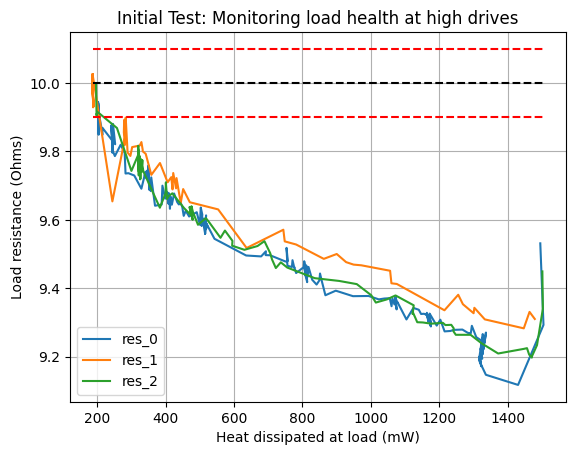

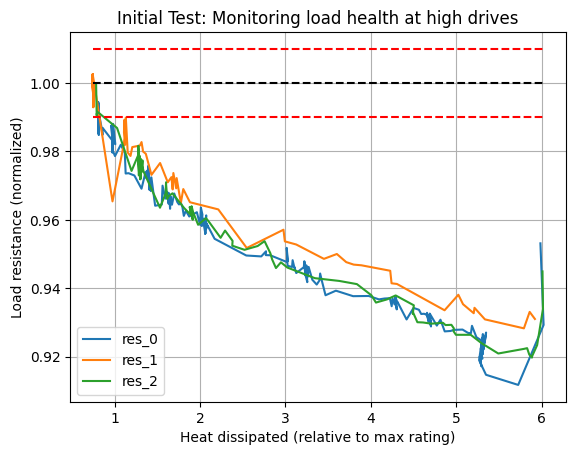

In [19]:
## Initial testing
# Non-normalized plot
plot_resistance(dfs_initial_clean, 
                x_axis="power", 
                ylabel="Load resistance (Ohms)",
                xlabel="Heat dissipated at load (mW)",
                title="Initial Test: Monitoring load health at high drives", 
                normalize_y=False, normalize_x_value=None)

# Normalized plot
plot_resistance(dfs_initial_clean, 
                x_axis="power", 
                ylabel="Load resistance (normalized)",
                xlabel="Heat dissipated (relative to max rating)",
                title="Initial Test: Monitoring load health at high drives", 
                normalize_y=True, normalize_x_value=250)

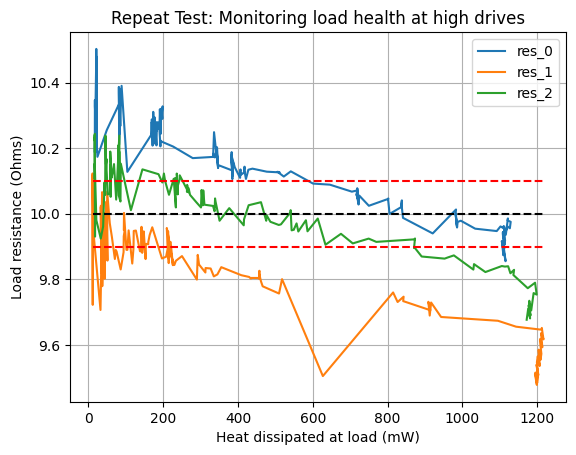

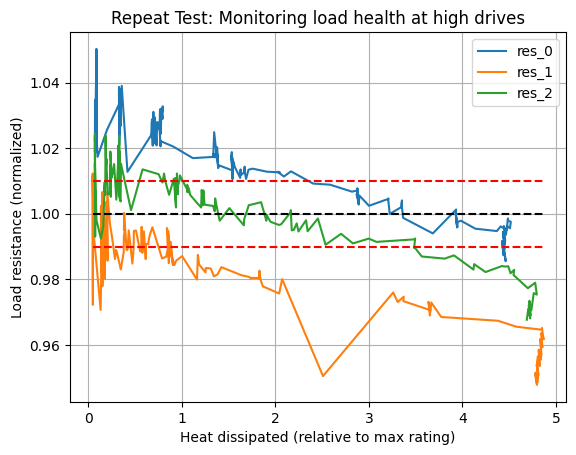

In [24]:
## Repeat test
# Non-normalized plot
plot_resistance(dfs_repeat_clean, 
                x_axis="power", 
                ylabel="Load resistance (Ohms)",
                xlabel="Heat dissipated at load (mW)",
                title="Repeat Test: Monitoring load health at high drives", 
                normalize_y=False, normalize_x_value=None)

# Normalized plot
plot_resistance(dfs_repeat_clean, 
                x_axis="power", 
                ylabel="Load resistance (normalized)",
                xlabel="Heat dissipated (relative to max rating)",
                title="Repeat Test: Monitoring load health at high drives", 
                normalize_y=True, normalize_x_value=250)